In [1]:
import pandas as pd
import polars as pl
import svy
import matplotlib.pyplot as plt

In [2]:
h2_df = pd.read_csv('../data/processed/h2_analytic_sample.csv')
h2_pooled = h2_df.assign(wtsaf2yr_pooled = h2_df['WTSAF2YR'] / 3)

design = svy.Design(
    stratum='SDMVSTRA',
    psu='SDMVPSU',
    wgt='wtsaf2yr_pooled'
)
h2_pl = pl.from_pandas(h2_pooled)
sample = svy.Sample(h2_pl, design=design)

/var/folders/rs/yth10b8d4v1043_hxt3sv4x40000gn/T/ipykernel_12475/315946088.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  h2_pooled = h2_df.assign(wtsaf2yr_pooled = h2_df['WTSAF2YR'] / 3)


In [4]:
from sklearn.metrics import roc_auc_score, roc_curve

h2_pooled['ft3_z'] = (h2_pooled['LBXT3F'] - h2_pooled['LBXT3F'].mean()) / h2_pooled['LBXT3F'].std()
h2_pooled['tsh_z'] = (h2_pooled['LBXTSH1'] - h2_pooled['LBXTSH1'].mean()) / h2_pooled['LBXTSH1'].std()

h2_pl = pl.from_pandas(h2_pooled)
sample = svy.Sample(h2_pl, design=design)

def fit_and_score(predictor_col):
    model = svy.GLM(sample)
    model.fit(
        y='metabolic_syndrome',
        x=[predictor_col, 'RIDAGEYR', svy.Cat('RIAGENDR', ref=1), 'BMXBMI'], family='binomial'
        )
    pred = model.predict(h2_pl)
    valid = ~pd.isna(pred.yhat)
    y_true = h2_pooled.loc[valid, 'metabolic_syndrome']
    y_score = pred.yhat[valid]
    w = h2_pooled.loc[valid, 'wtsaf2yr_pooled']
    auc = roc_auc_score(y_true, y_score, sample_weight=w)
    fpr, tpr, _ = roc_curve(y_true, y_score, sample_weight=w)
    return model, auc, fpr, tpr

model_t3, auc_t3, fpr_t3, tpr_t3 = fit_and_score('ft3_z')
model_tsh, auc_tsh, fpr_tsh, tpr_tsh = fit_and_score('tsh_z')

print(model_t3)
print(f'AUC = {auc_t3:.4f}')
print()
print(model_tsh)
print(f'AUC = {auc_tsh:.4f}')

GLM: Binomial (logit)
  Modeling : metabolic_syndrome
  n            : 3372          DF Residuals : 45
  Deviance     : 3265.3805     Scale        : 1.0000
  AIC          : 3283.9398     BIC          : -
  R-squared    : 0.26032       R-sq (adj)   : 0.25944
  F-stat (adj) : 99.23696      Prob (F-adj) : <0.001

Coefficients:
  Term          Coef.     Std.Err.  t          P>|t|   [0.025    0.975]  
  ------------  --------  --------  ---------  ------  --------  --------
  _intercept_   -9.08891  0.45077   -20.16326  <0.001  -9.99680  -8.18102
  ft3_z         0.32147   0.17121   1.87769    0.0669  -0.02335  0.66630 
  RIDAGEYR      0.05647   0.00451   12.50985   <0.001  0.04737   0.06556 
  RIAGENDR_2.0  -0.19053  0.13603   -1.40070   0.1682  -0.46451  0.08344 
  BMXBMI        0.20488   0.01176   17.41720   <0.001  0.18119   0.22857 
AUC = 0.8323

GLM: Binomial (logit)
  Modeling : metabolic_syndrome
  n            : 3372          DF Residuals : 45
  Deviance     : 3273.5580     Scale   

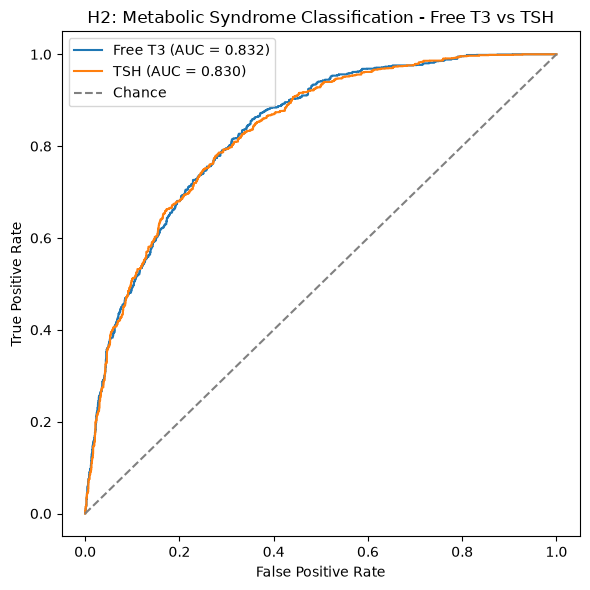

In [5]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(fpr_t3, tpr_t3, label=f'Free T3 (AUC = {auc_t3:.3f})')
ax.plot(fpr_tsh, tpr_tsh, label=f'TSH (AUC = {auc_tsh:.3f})')
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Chance')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('H2: Metabolic Syndrome Classification - Free T3 vs TSH')
ax.legend()
plt.tight_layout()
plt.show()

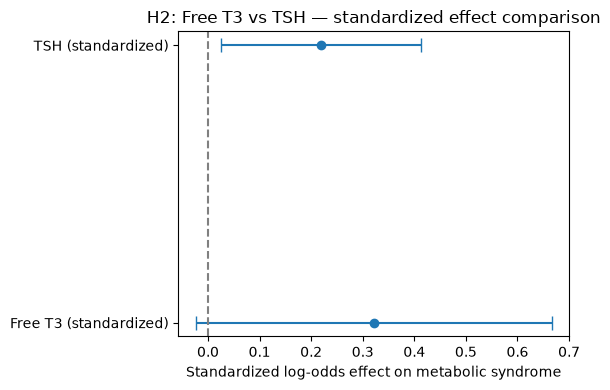

In [6]:
t3_row = model_t3.to_polars().filter(pl.col('term') == 'ft3_z').to_pandas()
t3_row['model'] = 'Free T3 (standardized)'

tsh_row = model_tsh.to_polars().filter(pl.col('term') == 'tsh_z').to_pandas()
tsh_row['model'] = 'TSH (standardized)'

coef_comparison = pd.concat([t3_row, tsh_row], ignore_index=True)

fig, ax = plt.subplots(figsize=(6, 4))
ax.errorbar(
    x=coef_comparison['estimate'],
    y=coef_comparison['model'],
    xerr=[
        coef_comparison['estimate'] - coef_comparison['conf_low'],
        coef_comparison['conf_high'] - coef_comparison['estimate'],
    ],
    fmt='o',
    capsize=5,
)
ax.axvline(0, linestyle='--', color='gray')
ax.set_xlabel('Standardized log-odds effect on metabolic syndrome')
ax.set_title('H2: Free T3 vs TSH — standardized effect comparison')
plt.tight_layout()
plt.show()